<a href="https://colab.research.google.com/github/HTKhuongNinh-FPTU/Employee-Attrition-Analysis/blob/main/XG_Boost_Regression_Attrition_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Phân tích yếu tố ảnh hưởng và dự báo nghỉ việc bằng XG Boost Regression.**

**Phần 1: Khai báo thư viện & Tải dữ liệu**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, mean_squared_error, r2_score
from xgboost import XGBClassifier
from sklearn.linear_model import LinearRegression

# Tải file lên
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

print(f"Đã tải thành công: {file_name}")
print("Kích thước dữ liệu:", df.shape)
df.head()

Saving hr_cleaned_12_cols.csv to hr_cleaned_12_cols (3).csv
Đã tải thành công: hr_cleaned_12_cols (3).csv
Kích thước dữ liệu: (1058, 12)


,Attrition,Age,Department,JobRole,JobLevel,MonthlyIncome,OverTime,DistanceFromHome,JobSatisfaction,EnvironmentSatisfaction,TotalWorkingYears,YearsAtCompany
0,Left,37,Research & Development,Healthcare Representative,2,4777.000,No,11,2,1,15,1
1,Left,51,Research & Development,Research Scientist,1,2461.000,Yes,4,3,1,18,10
2,Stayed,42,Sales,Sales Executive,4,13525.000,No,26,2,3,23,20
3,Stayed,40,Sales,Sales Executive,2,7457.000,Yes,1,4,2,6,4
4,Left,55,Research & Development,Manager,5,17490.875,Yes,2,1,4,24,5


**Phần 2: Tiền xử lý & Loại bỏ biến (Loại bỏ Dept/JobRole)**

In [ ]:
# 1. Loại bỏ các cột không đưa vào mô hình
df_ml = df.drop(columns=['Department', 'JobRole'])

# 2. Mã hóa biến mục tiêu và biến phân loại
# Attrition: Left -> 1, Stayed -> 0
df_ml['Attrition'] = df_ml['Attrition'].map({'Left': 1, 'Stayed': 0})
# OverTime: Yes -> 1, No -> 0
df_ml['OverTime'] = df_ml['OverTime'].map({'Yes': 1, 'No': 0})

# 3. Tách X, y và chia tập dữ liệu 8/2
X = df_ml.drop('Attrition', axis=1)
y = df_ml['Attrition']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("--- THÔNG SỐ CHIA DỮ LIỆU ---")
print(f"Tập huấn luyện: {X_train.shape[0]} dòng")
print(f"Tập kiểm tra: {X_test.shape[0]} dòng")
df_ml.head()

--- THÔNG SỐ CHIA DỮ LIỆU ---
Tập huấn luyện: 846 dòng
Tập kiểm tra: 212 dòng


,Attrition,Age,JobLevel,MonthlyIncome,OverTime,DistanceFromHome,JobSatisfaction,EnvironmentSatisfaction,TotalWorkingYears,YearsAtCompany
0,1,37,2,4777.000,0,11,2,1,15,1
1,1,51,1,2461.000,1,4,3,1,18,10
2,0,42,4,13525.000,0,26,2,3,23,20
3,0,40,2,7457.000,1,1,4,2,6,4
4,1,55,5,17490.875,1,2,1,4,24,5


**Phần 3: Chia dữ liệu & Huấn luyện mô hình**

In [ ]:
# Tách đặc trưng (X) và mục tiêu (y)
X = df_ml.drop('Attrition', axis=1)
y = df_ml['Attrition']

# Chia dữ liệu theo tỷ lệ 80% huấn luyện - 20% kiểm tra
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\n--- THÔNG SỐ CHIA DỮ LIỆU ---")
print(f"Tổng số mẫu: {len(df_ml)}")
print(f"Mẫu huấn luyện (X_train): {X_train.shape[0]}")
print(f"Mẫu kiểm tra (X_test): {X_test.shape[0]}")

# ==========================================
# PHẦN 4: HUẤN LUYỆN MÔ HÌNH XGBOOST
# ==========================================
# Khởi tạo mô hình với các tham số tối ưu cơ bản
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
    eval_metric='logloss'
)

# Tiến hành huấn luyện trên tập Train
print("\n🚀 Đang huấn luyện mô hình XGBoost...")
xgb_model.fit(X_train, y_train)
print("✅ Huấn luyện hoàn tất!")


--- THÔNG SỐ CHIA DỮ LIỆU ---
Tổng số mẫu: 1058
Mẫu huấn luyện (X_train): 846
Mẫu kiểm tra (X_test): 212

🚀 Đang huấn luyện mô hình XGBoost...
✅ Huấn luyện hoàn tất!


**Phần 4: Bảng Mức Độ Quan Trọng**

In [ ]:
# 1. Cấu hình hiển thị
pd.set_option('display.max_colwidth', None)

# 2. Trích xuất mức độ quan trọng (Feature Importances) từ XGBoost
feature_importances = xgb_model.feature_importances_
features = X.columns.tolist()

# 3. Tạo DataFrame báo cáo và sắp xếp giảm dần
importance_df = pd.DataFrame({
    'Đặc trưng': features,
    'Mức độ đóng góp (%)': feature_importances * 100
})
importance_df = importance_df.sort_values(by='Mức độ đóng góp (%)', ascending=False)

# 4. Định dạng lại cột hiển thị
importance_df['Mức độ đóng góp (%)'] = importance_df['Mức độ đóng góp (%)'].apply(lambda x: f"{x:.2f}%")

# In kết quả
print(f"{'--- BẢNG MỨC ĐỘ QUAN TRỌNG NHÂN SỰ (XGBOOST) ---':^60}")
print(importance_df.to_string(index=False))

      --- BẢNG MỨC ĐỘ QUAN TRỌNG NHÂN SỰ (XGBOOST) ---      
              Đặc trưng Mức độ đóng góp (%)
               OverTime              29.10%
               JobLevel              11.51%
EnvironmentSatisfaction              10.91%
        JobSatisfaction               8.87%
         YearsAtCompany               8.83%
          MonthlyIncome               8.70%
      TotalWorkingYears               8.24%
       DistanceFromHome               6.93%
                    Age               6.92%


**Phần 5: Đánh giá & Trực quan hóa**

     --- KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH XGBOOST ---     
1. Độ chính xác tổng thể (Accuracy): 84.43%
2. Độ chính xác dự báo nghỉ (Precision): 66.67%
3. Khả năng tìm thấy người nghỉ (Recall): 30.77%
4. Điểm cân bằng (F1-Score): 42.11%
--------------------------------------------------


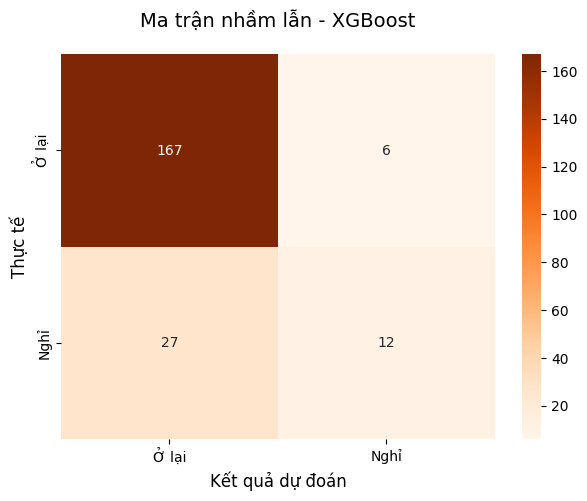

In [ ]:
# 1. Dự đoán trên tập kiểm tra
y_pred_xgb = xgb_model.predict(X_test)

# 2. Tính toán các chỉ số chính
acc_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

# 3. Hiển thị báo cáo chi tiết
print(f"{'--- KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH XGBOOST ---':^50}")
print(f"1. Độ chính xác tổng thể (Accuracy): {acc_xgb:.2%}")
print(f"2. Độ chính xác dự báo nghỉ (Precision): {precision_xgb:.2%}")
print(f"3. Khả năng tìm thấy người nghỉ (Recall): {recall_xgb:.2%}")
print(f"4. Điểm cân bằng (F1-Score): {f1_xgb:.2%}")
print("-" * 50)

# 4. Vẽ Ma trận nhầm lẫn (Confusion Matrix)
plt.figure(figsize=(7, 5))
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Ở lại', 'Nghỉ'],
            yticklabels=['Ở lại', 'Nghỉ'])

plt.title('Ma trận nhầm lẫn - XGBoost', fontsize=14, pad=20)
plt.xlabel('Kết quả dự đoán', fontsize=12)
plt.ylabel('Thực tế', fontsize=12)
plt.show()